# 03 — Exploratory Data Analysis (Forecasting Edition)
**PTB-XL ECG Dataset — Frankfurt University of Applied Sciences**

This EDA notebook is aligned with the **time-series forecasting** task defined in `02_preprocessing.ipynb`.
The dataset is treated as a **regression problem** (predict future signal, not diagnose a class),
so all analyses are reframed around signal properties, temporal structure, and forecasting-relevant features.

Figures are saved to `reports/figures/`.

In [1]:
# CELL 1: IMPORTS
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal, stats
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

SAVE_DIR   = os.path.join('..', 'data', 'processed')
FIG_DIR    = os.path.join('..', 'reports', 'figures')
LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
COLORS     = ['#6366f1','#0ea5e9','#10b981','#f59e0b','#ef4444']
FS         = 100
INPUT_LEN  = 500    # 5s encoder input
HORIZON    = 100    # 1s forecast target

for sub in ['signal','temporal','frequency','leads','forecast','quality','dynamics']:
    os.makedirs(os.path.join(FIG_DIR, sub), exist_ok=True)

print('Imports OK ✅')


Imports OK ✅


### Load Data — Forecasting Arrays from Preprocessing

We load `X_clean.npy` (full preprocessed records) and the windowed splits.
**No class labels are loaded** — this is a regression task.

In [2]:
# CELL 2: LOAD DATA
X       = np.load(os.path.join(SAVE_DIR, 'X_clean.npy'))   # (200, 1000, 12) full records
X_train = np.load(os.path.join(SAVE_DIR, 'X_train.npy'))   # (635, 500, 12) encoder inputs
y_train = np.load(os.path.join(SAVE_DIR, 'y_train.npy'))   # (635, 100, 12) forecast targets
X_val   = np.load(os.path.join(SAVE_DIR, 'X_val.npy'))
y_val   = np.load(os.path.join(SAVE_DIR, 'y_val.npy'))
X_test  = np.load(os.path.join(SAVE_DIR, 'X_test.npy'))
y_test  = np.load(os.path.join(SAVE_DIR, 'y_test.npy'))
df      = pd.read_pickle(os.path.join(SAVE_DIR, 'metadata.pkl'))
batch_df = df.iloc[:len(X)].copy()

print('=== FORECASTING EDA DATA SUMMARY ===')
print(f'Full records     : {X.shape}  (records x samples x leads)')
print(f'Train windows    : X={X_train.shape}  y={y_train.shape}')
print(f'Val windows      : X={X_val.shape}    y={y_val.shape}')
print(f'Test windows     : X={X_test.shape}   y={y_test.shape}')
print(f'\nNOTE: Targets are continuous mV values, not class labels. ✅')


=== FORECASTING EDA DATA SUMMARY ===
Full records     : (200, 1000, 12)  (records x samples x leads)
Train windows    : X=(635, 500, 12)  y=(635, 100, 12)
Val windows      : X=(210, 500, 12)    y=(210, 100, 12)
Test windows     : X=(155, 500, 12)   y=(155, 100, 12)

NOTE: Targets are continuous mV values, not class labels. ✅


## Section 1 — Dataset Overview & Window Statistics

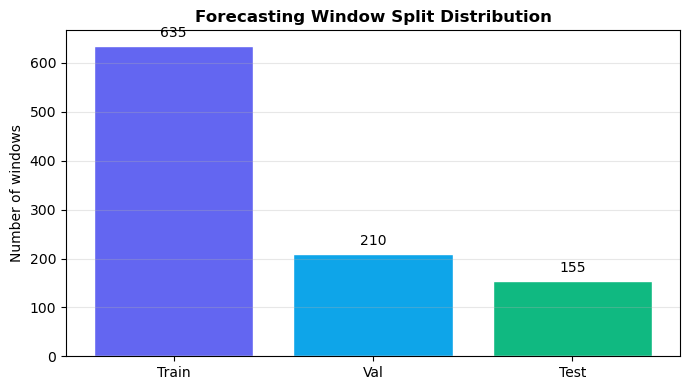

Total windows: 1000  |  Train 63.5%  Val 21.0%  Test 15.5%


In [3]:
# CELL 3: 1.1 Window count and split distribution
split_counts = {'Train': len(X_train), 'Val': len(X_val), 'Test': len(X_test)}
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(split_counts.keys(), split_counts.values(),
              color=['#6366f1','#0ea5e9','#10b981'], edgecolor='white')
ax.bar_label(bars, fmt='%d', padding=4)
ax.set_ylabel('Number of windows')
ax.set_title('Forecasting Window Split Distribution', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'signal','1_1_split_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Total windows: {sum(split_counts.values())}  |  '
      f"Train {split_counts['Train']/sum(split_counts.values())*100:.1f}%  "
      f"Val {split_counts['Val']/sum(split_counts.values())*100:.1f}%  "
      f"Test {split_counts['Test']/sum(split_counts.values())*100:.1f}%")


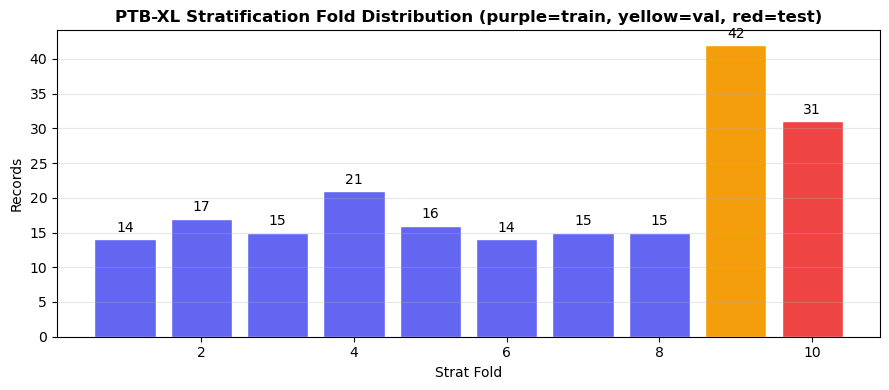

In [4]:
# CELL 4: 1.2 Strat-fold distribution (patient-safe split)
fold_counts = batch_df['strat_fold'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
fold_colors = ['#6366f1']*8 + ['#f59e0b', '#ef4444']  # 1-8 train, 9 val, 10 test
bars = ax.bar(fold_counts.index, fold_counts.values, color=fold_colors, edgecolor='white')
ax.bar_label(bars, fmt='%d', padding=3)
ax.set_xlabel('Strat Fold')
ax.set_ylabel('Records')
ax.set_title('PTB-XL Stratification Fold Distribution (purple=train, yellow=val, red=test)',
             fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'signal','1_2_fold_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()


## Section 2 — Signal Morphology

Morphological analysis of the preprocessed ECG signal. Since we have no class labels,
we analyse the distribution of signal statistics across all windows and all leads.

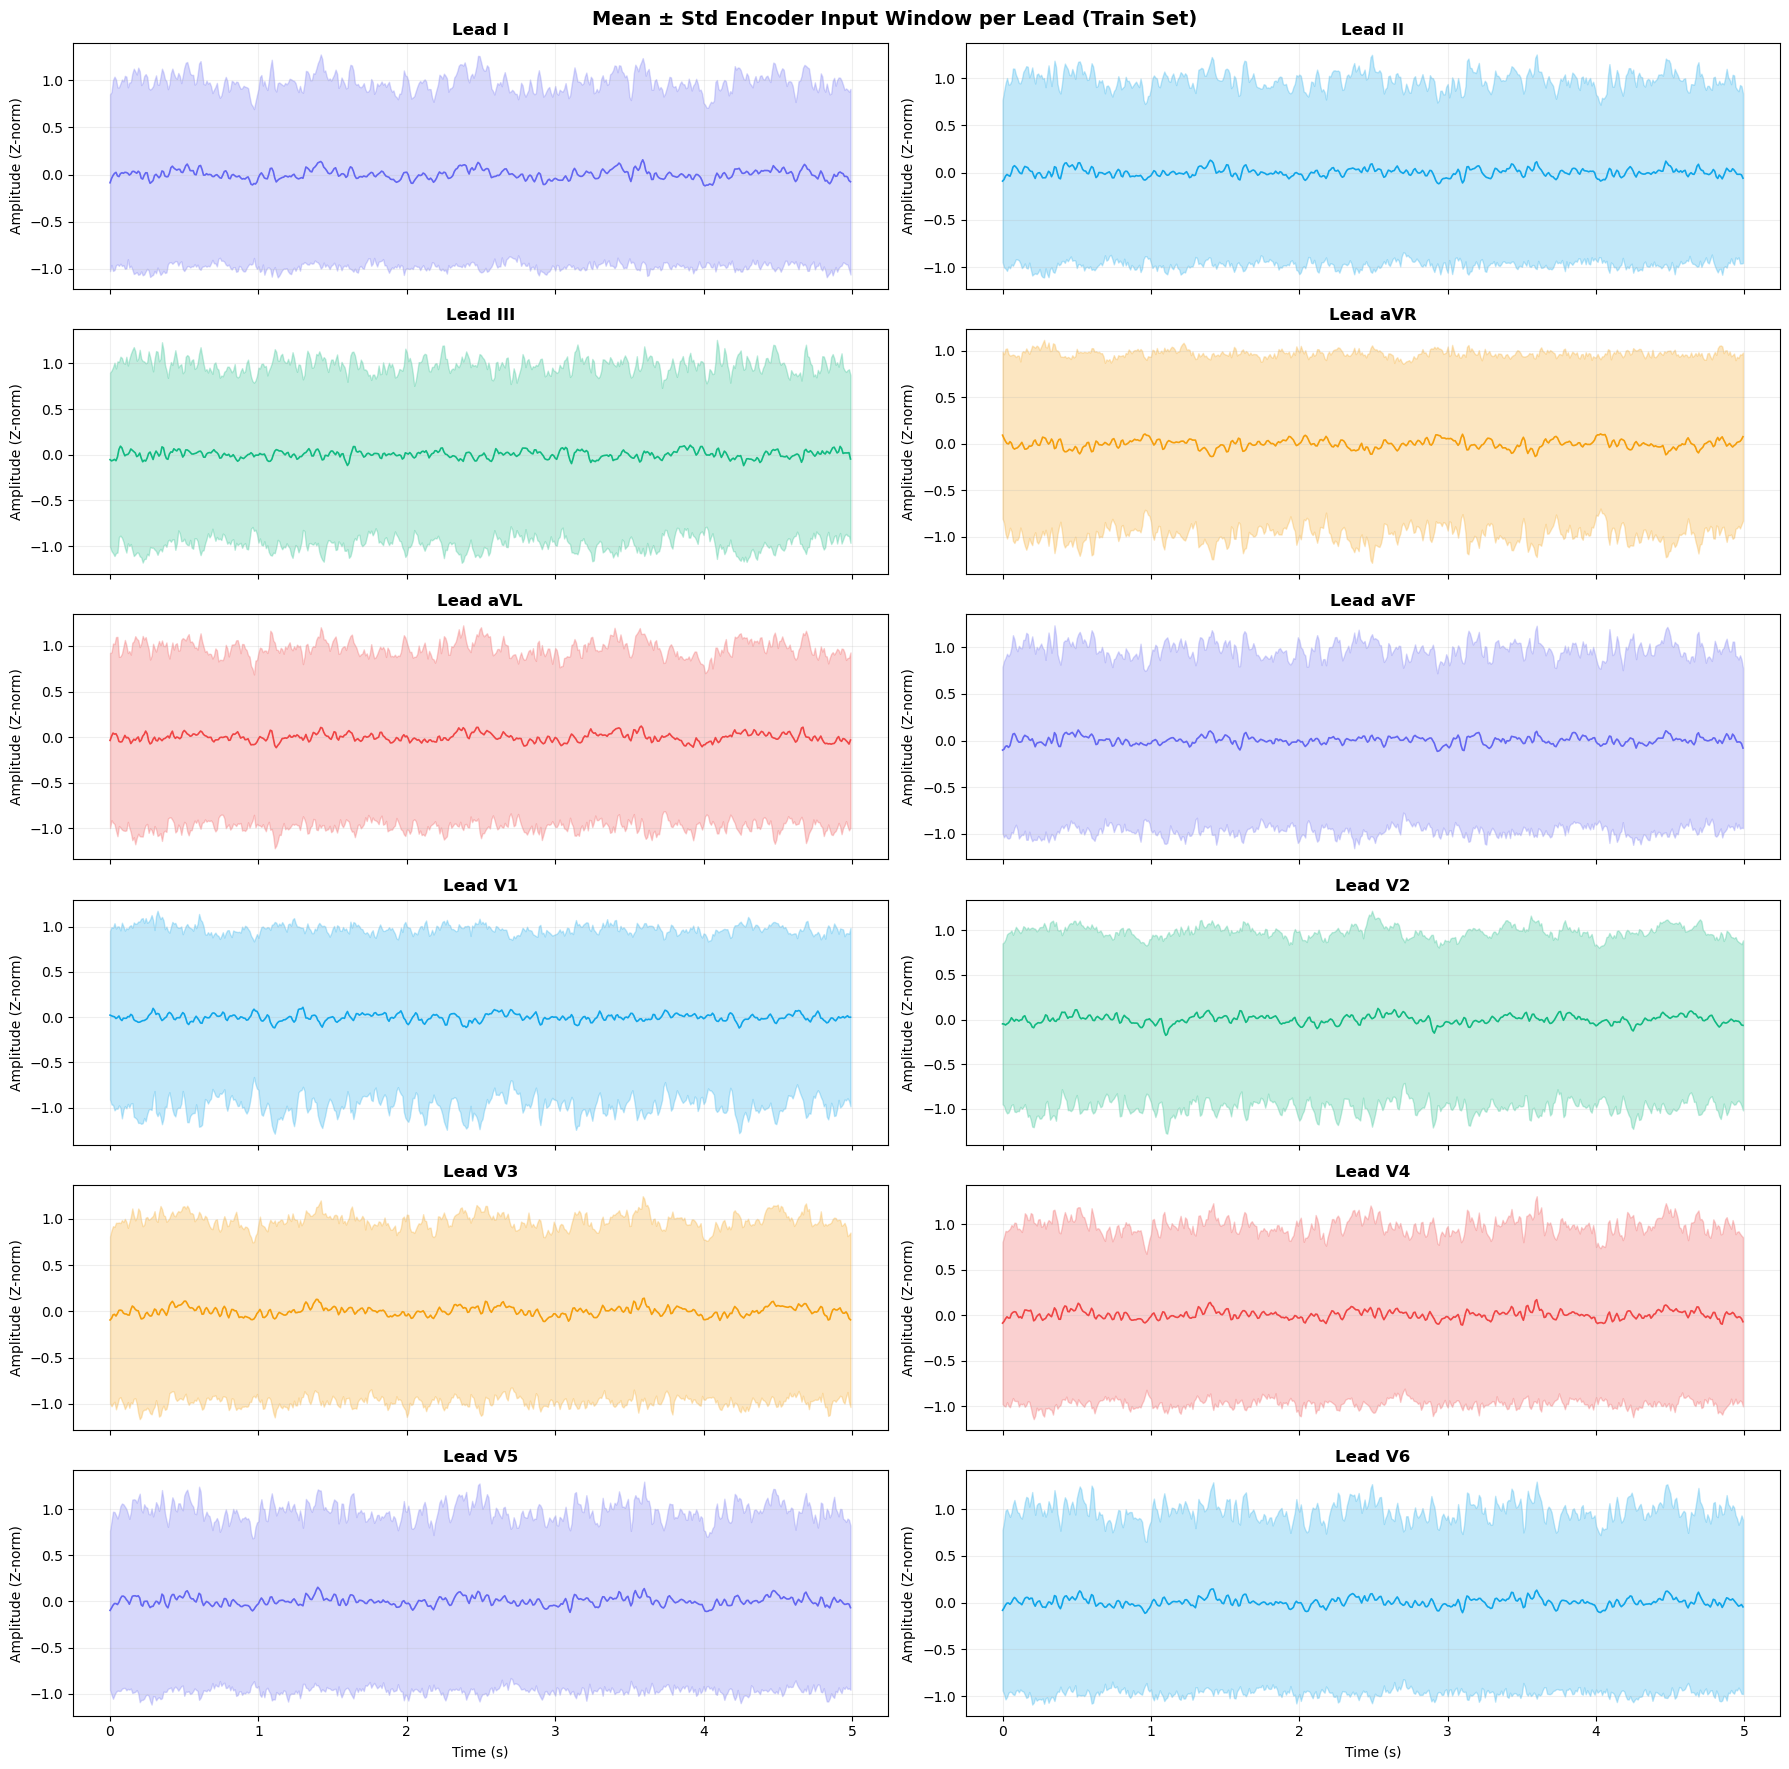

In [5]:
# CELL 5: 2.1 Mean ± Std ECG per lead (all training windows)
t = np.arange(INPUT_LEN) / FS
fig, axes = plt.subplots(6, 2, figsize=(18, 18), sharex=True)
axes = axes.flatten()
for li, (lead, ax) in enumerate(zip(LEAD_NAMES, axes)):
    mean_w = X_train[:, :, li].mean(axis=0)
    std_w  = X_train[:, :, li].std(axis=0)
    ax.plot(t, mean_w, color=COLORS[li % len(COLORS)], lw=1.2, label='Mean')
    ax.fill_between(t, mean_w-std_w, mean_w+std_w,
                    alpha=0.25, color=COLORS[li % len(COLORS)], label='±1σ')
    ax.set_title(f'Lead {lead}', fontweight='bold')
    ax.set_ylabel('Amplitude (Z-norm)')
    ax.grid(True, alpha=0.2)
    if li >= 10: ax.set_xlabel('Time (s)')
fig.suptitle('Mean ± Std Encoder Input Window per Lead (Train Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'signal','2_1_mean_std_per_lead.png'), dpi=150, bbox_inches='tight')
plt.show()


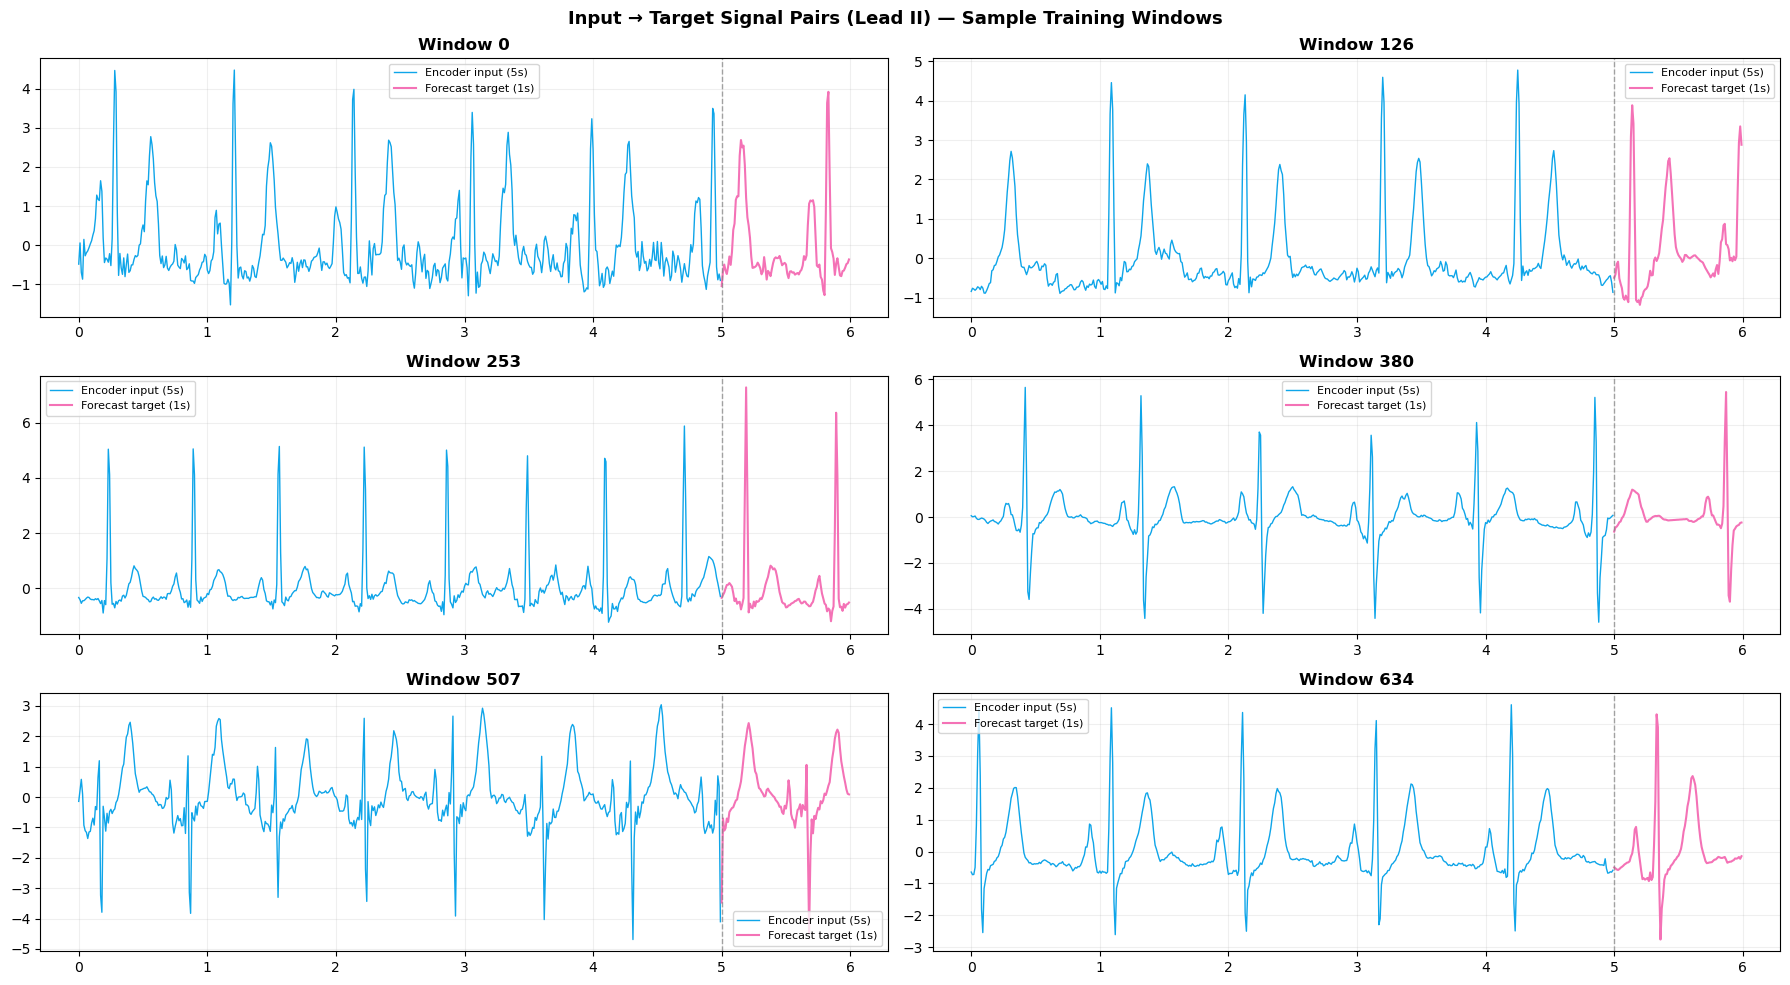

In [6]:
# CELL 6: 2.2 Input vs Target signal comparison (Lead II, 6 sample windows)
t_in  = np.arange(INPUT_LEN) / FS
t_out = np.arange(HORIZON) / FS + INPUT_LEN/FS
fig, axes = plt.subplots(3, 2, figsize=(18, 10), sharey=False)
axes = axes.flatten()
indices = np.linspace(0, len(X_train)-1, 6, dtype=int)
for idx, ax in zip(indices, axes):
    ax.plot(t_in,  X_train[idx, :, 1], color='#0ea5e9', lw=1.0, label='Encoder input (5s)')
    ax.plot(t_out, y_train[idx, :, 1], color='#f472b6', lw=1.5, label='Forecast target (1s)')
    ax.axvline(INPUT_LEN/FS, color='gray', ls='--', lw=1, alpha=0.7)
    ax.set_title(f'Window {idx}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
fig.suptitle('Input → Target Signal Pairs (Lead II) — Sample Training Windows',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'forecast','2_2_input_target_pairs.png'), dpi=150, bbox_inches='tight')
plt.show()


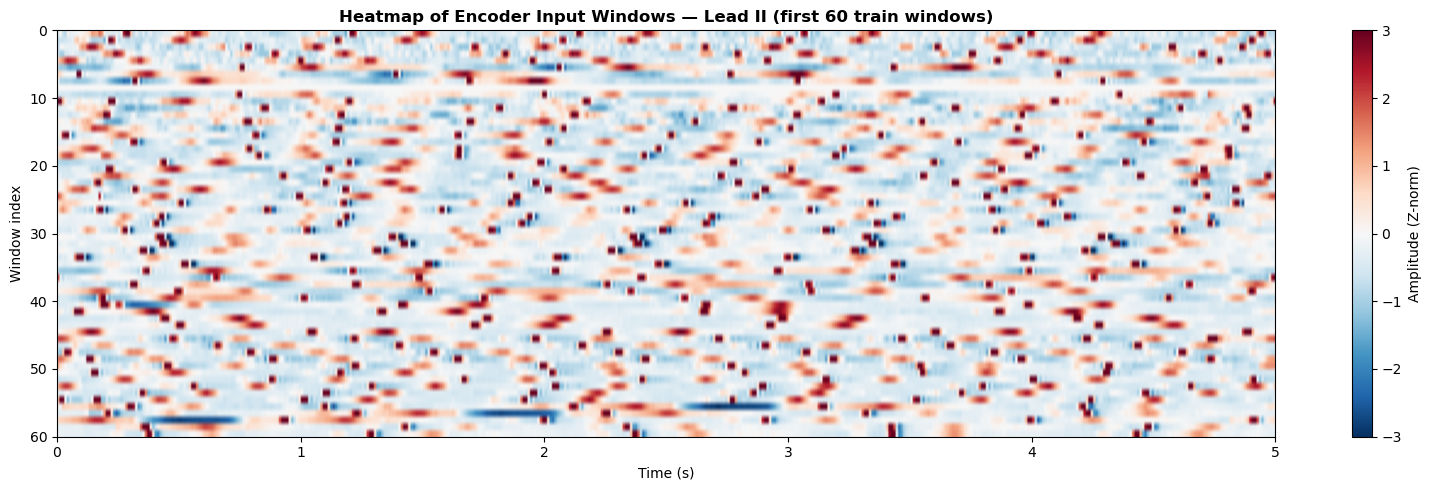

In [7]:
# CELL 7: 2.3 Beat-aligned heatmap per lead (Lead II, first 60 windows)
fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(X_train[:60, :, 1], aspect='auto', cmap='RdBu_r',
               vmin=-3, vmax=3, extent=[0, INPUT_LEN/FS, 60, 0])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Window index')
ax.set_title('Heatmap of Encoder Input Windows — Lead II (first 60 train windows)',
             fontweight='bold')
plt.colorbar(im, ax=ax, label='Amplitude (Z-norm)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'signal','2_3_window_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


## Section 3 — Time-Domain Statistics

Statistics computed over the full preprocessed records and the windowed splits.

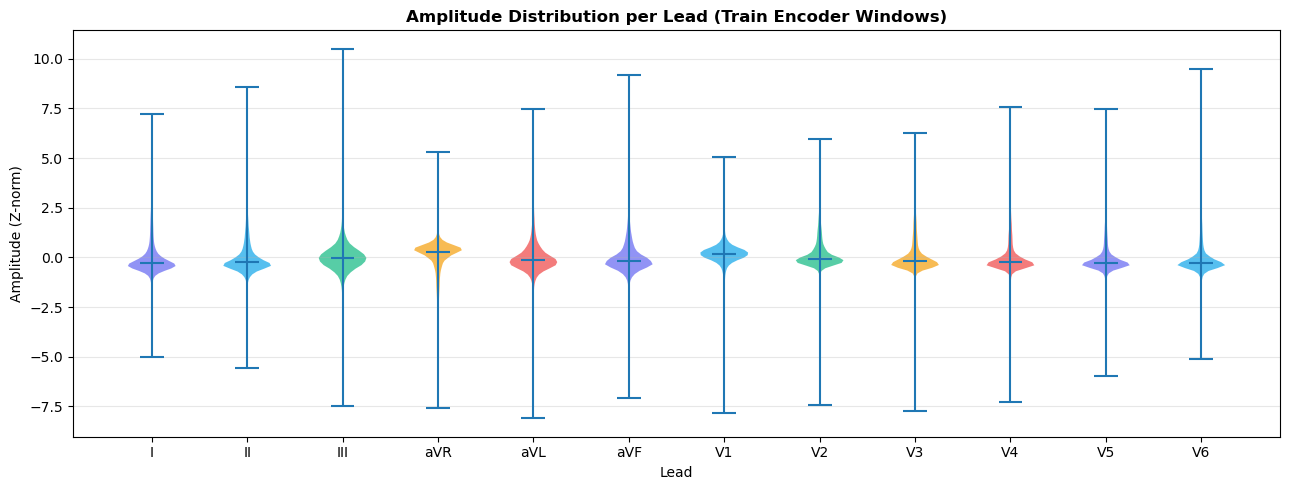

In [8]:
# CELL 8: 3.1 Amplitude distribution per lead (training encoder windows)
fig, ax = plt.subplots(figsize=(13, 5))
data = [X_train[:, :, i].flatten() for i in range(12)]
parts = ax.violinplot(data, positions=range(12), showmedians=True)
for pc, col in zip(parts['bodies'], [COLORS[i % len(COLORS)] for i in range(12)]):
    pc.set_facecolor(col); pc.set_alpha(0.7)
ax.set_xticks(range(12)); ax.set_xticklabels(LEAD_NAMES)
ax.set_xlabel('Lead')
ax.set_ylabel('Amplitude (Z-norm)')
ax.set_title('Amplitude Distribution per Lead (Train Encoder Windows)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'temporal','3_1_amplitude_dist.png'), dpi=150, bbox_inches='tight')
plt.show()


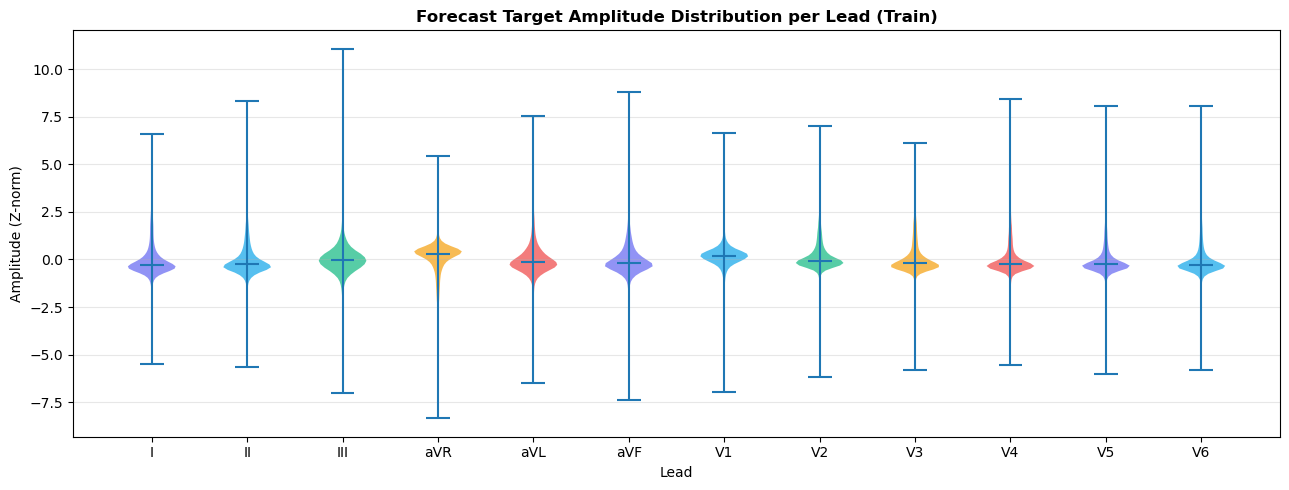

In [9]:
# CELL 9: 3.2 Target amplitude distribution (forecast horizon)
fig, ax = plt.subplots(figsize=(13, 5))
data_tgt = [y_train[:, :, i].flatten() for i in range(12)]
parts = ax.violinplot(data_tgt, positions=range(12), showmedians=True)
for pc, col in zip(parts['bodies'], [COLORS[i % len(COLORS)] for i in range(12)]):
    pc.set_facecolor(col); pc.set_alpha(0.7)
ax.set_xticks(range(12)); ax.set_xticklabels(LEAD_NAMES)
ax.set_xlabel('Lead')
ax.set_ylabel('Amplitude (Z-norm)')
ax.set_title('Forecast Target Amplitude Distribution per Lead (Train)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'temporal','3_2_target_amplitude_dist.png'), dpi=150, bbox_inches='tight')
plt.show()


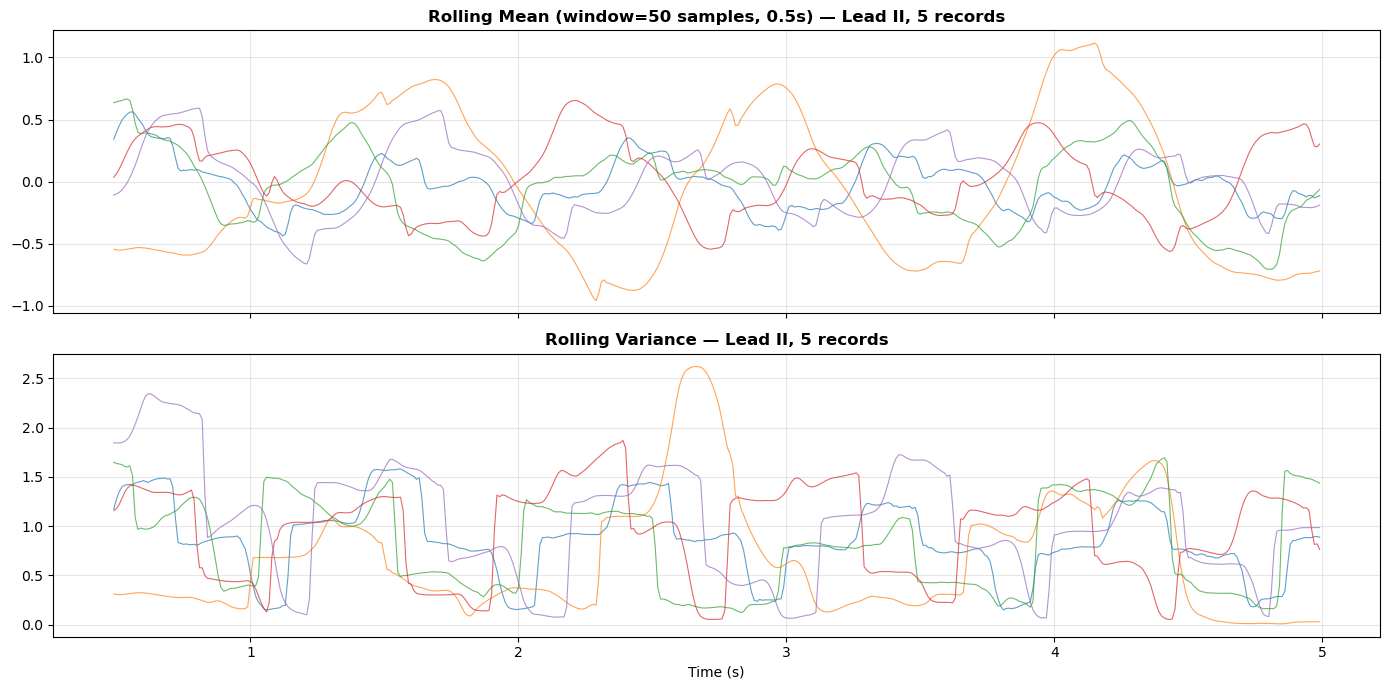

In [10]:
# CELL 10: 3.3 Rolling mean and variance (Lead II, full records)
window_r = 50
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for rec_idx in range(min(5, len(X))):
    s = pd.Series(X[rec_idx, :INPUT_LEN, 1])
    t_roll = np.arange(INPUT_LEN) / FS
    axes[0].plot(t_roll, s.rolling(window_r).mean(), lw=0.8, alpha=0.7)
    axes[1].plot(t_roll, s.rolling(window_r).var(),  lw=0.8, alpha=0.7)
axes[0].set_title('Rolling Mean (window=50 samples, 0.5s) — Lead II, 5 records', fontweight='bold')
axes[1].set_title('Rolling Variance — Lead II, 5 records', fontweight='bold')
axes[1].set_xlabel('Time (s)')
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'temporal','3_3_rolling_stats.png'), dpi=150, bbox_inches='tight')
plt.show()


## Section 4 — Frequency and Spectral Analysis

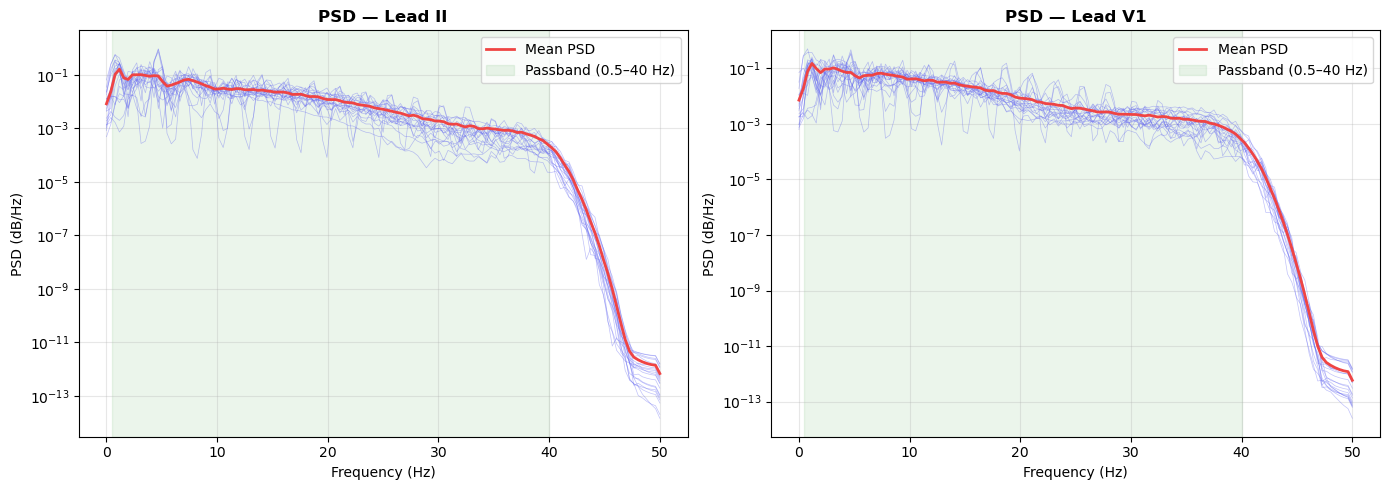

In [11]:
# CELL 11: 4.1 Power Spectral Density — per lead (Lead II vs V1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, li, lead in zip(axes, [1, 6], ['II', 'V1']):
    for rec_idx in range(min(20, len(X))):
        f, psd = signal.welch(X[rec_idx, :, li], fs=FS, nperseg=256)
        ax.semilogy(f, psd, lw=0.5, alpha=0.4, color='#6366f1')
    # Mean PSD
    psds = [signal.welch(X[i, :, li], fs=FS, nperseg=256)[1] for i in range(len(X))]
    f_ref, _ = signal.welch(X[0, :, li], fs=FS, nperseg=256)
    ax.semilogy(f_ref, np.mean(psds, axis=0), lw=2, color='#ef4444', label='Mean PSD')
    ax.axvspan(0.5, 40, alpha=0.08, color='green', label='Passband (0.5–40 Hz)')
    ax.set_title(f'PSD — Lead {lead}', fontweight='bold')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD (dB/Hz)')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'frequency','4_1_psd_per_lead.png'), dpi=150, bbox_inches='tight')
plt.show()


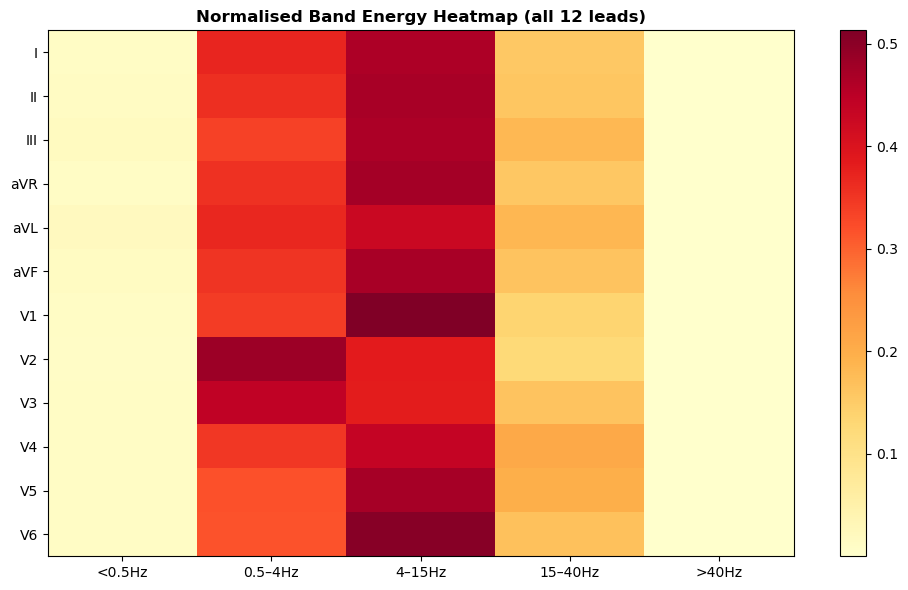

In [12]:
# CELL 12: 4.2 Frequency band energy heatmap (all leads)
bands = {'<0.5Hz':(0,0.5),'0.5–4Hz':(0.5,4),'4–15Hz':(4,15),
         '15–40Hz':(15,40),'>40Hz':(40,50)}
energy = np.zeros((12, len(bands)))
for li in range(12):
    for bi, (bname, (lo, hi)) in enumerate(bands.items()):
        band_e = []
        for rec in X[:, :, li]:
            f, psd = signal.welch(rec, fs=FS, nperseg=256)
            m = (f >= lo) & (f < hi)
            band_e.append(psd[m].sum() if m.any() else 0)
        energy[li, bi] = np.mean(band_e)
energy_norm = energy / (energy.sum(axis=1, keepdims=True) + 1e-8)
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(energy_norm, cmap='YlOrRd', aspect='auto')
ax.set_yticks(range(12)); ax.set_yticklabels(LEAD_NAMES)
ax.set_xticks(range(len(bands))); ax.set_xticklabels(list(bands.keys()))
ax.set_title('Normalised Band Energy Heatmap (all 12 leads)', fontweight='bold')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'frequency','4_2_band_energy.png'), dpi=150, bbox_inches='tight')
plt.show()


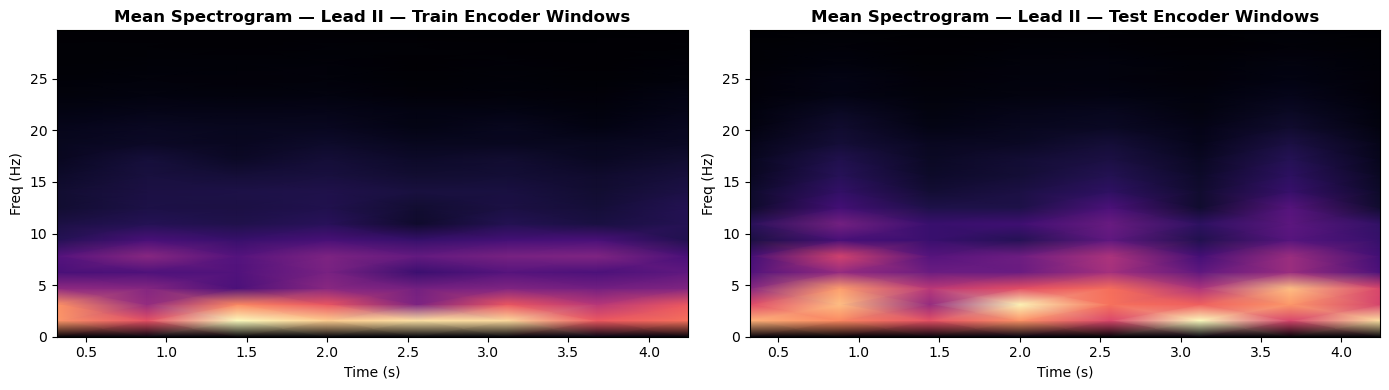

In [13]:
# CELL 13: 4.3 Mean spectrogram (Lead II, 10 sample windows)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, split_X, title in zip(axes,
    [X_train[:, :, 1], X_test[:, :, 1]],
    ['Train Encoder Windows', 'Test Encoder Windows']):
    specs = []
    for rec in split_X[:20]:
        f_s, t_s, Sxx = signal.spectrogram(rec, fs=FS, nperseg=64)
        specs.append(Sxx)
    mean_spec = np.mean(specs, axis=0)
    ax.pcolormesh(t_s, f_s[:20], mean_spec[:20], shading='gouraud', cmap='magma')
    ax.set_title(f'Mean Spectrogram — Lead II — {title}', fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Freq (Hz)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'frequency','4_3_spectrograms.png'), dpi=150, bbox_inches='tight')
plt.show()


## Section 5 — Inter-Lead Relationships

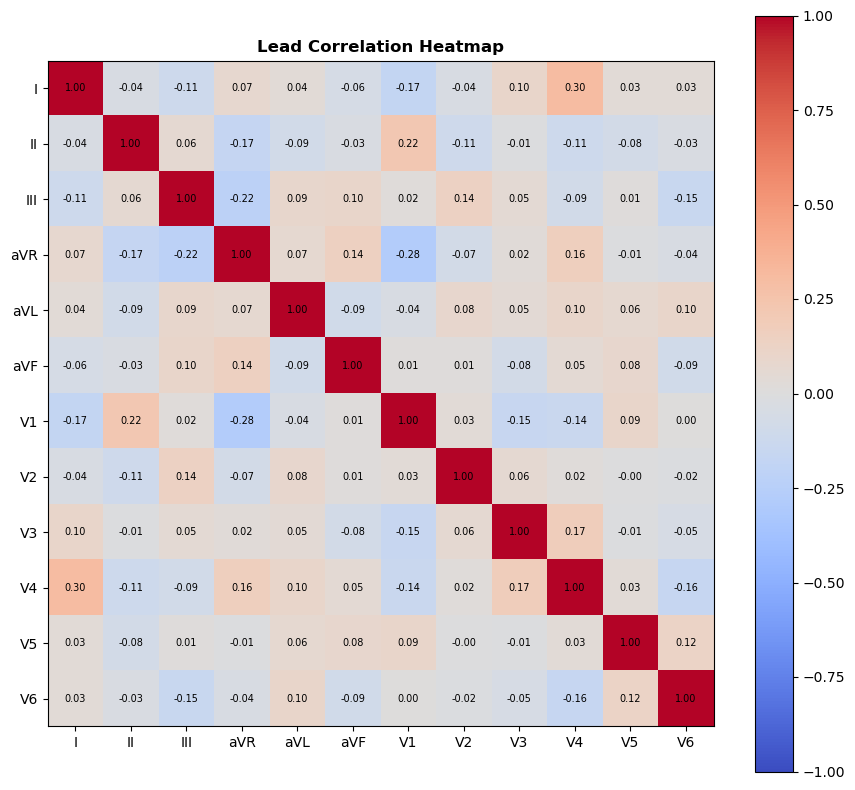

In [14]:
# CELL 14: 5.1 Lead correlation heatmap
per_lead_mean = X.mean(axis=1)   # (N, 12)
corr_mat = np.corrcoef(per_lead_mean.T)
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr_mat, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(12)); ax.set_xticklabels(LEAD_NAMES)
ax.set_yticks(range(12)); ax.set_yticklabels(LEAD_NAMES)
for i in range(12):
    for j in range(12):
        ax.text(j, i, f'{corr_mat[i,j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax)
ax.set_title('Lead Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'leads','5_1_lead_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()


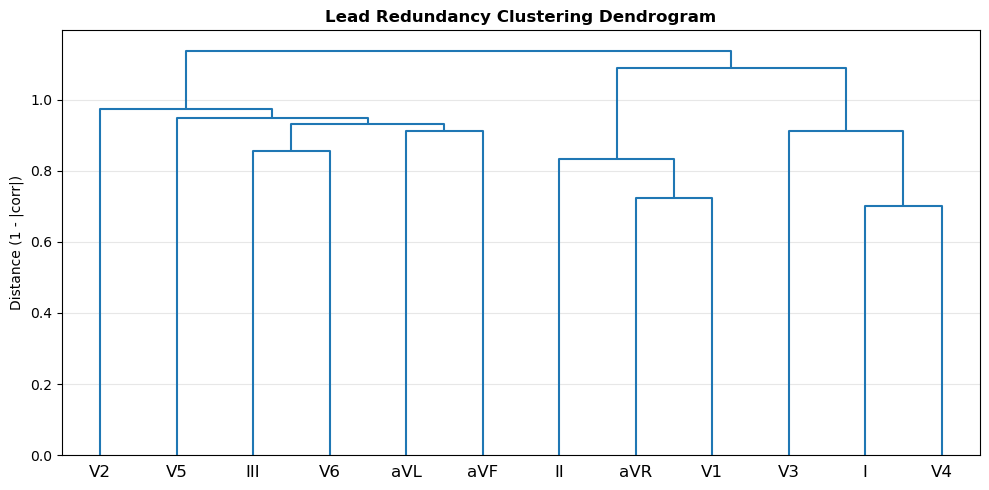

In [15]:
# CELL 15: 5.2 Lead redundancy clustering dendrogram
dist_mat = 1 - np.abs(corr_mat)
np.fill_diagonal(dist_mat, 0)
linkage  = hierarchy.linkage(squareform((dist_mat + dist_mat.T)/2), method='ward')
fig, ax  = plt.subplots(figsize=(10, 5))
hierarchy.dendrogram(linkage, labels=LEAD_NAMES, ax=ax,
                     color_threshold=0.5, leaf_font_size=12)
ax.set_title('Lead Redundancy Clustering Dendrogram', fontweight='bold')
ax.set_ylabel('Distance (1 - |corr|)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'leads','5_2_lead_dendrogram.png'), dpi=150, bbox_inches='tight')
plt.show()


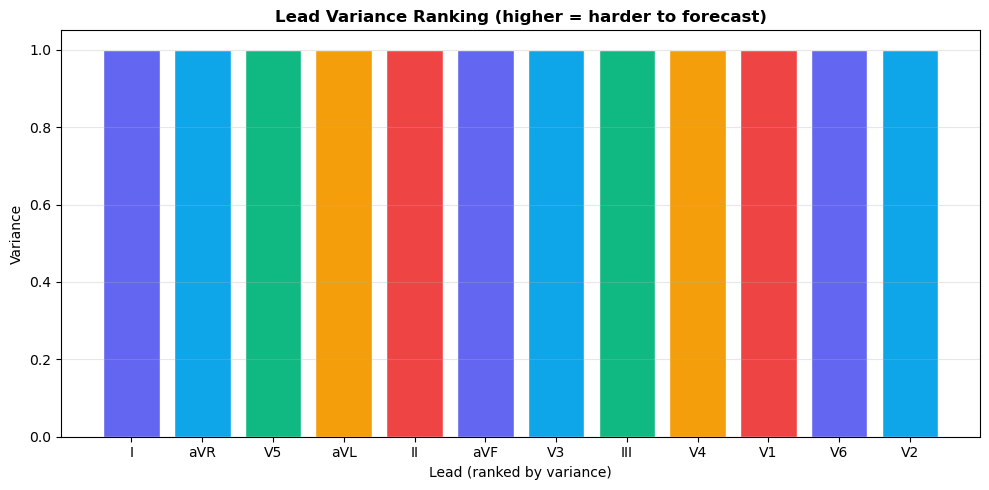

In [16]:
# CELL 16: 5.3 Lead variance ranking (forecasting-relevant: high-variance leads are harder to predict)
lead_var = X.var(axis=(0, 1))
ranked   = np.argsort(lead_var)[::-1]
fig, ax  = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(12), lead_var[ranked],
              color=[COLORS[i % len(COLORS)] for i in range(12)], edgecolor='white')
ax.set_xticks(range(12)); ax.set_xticklabels([LEAD_NAMES[i] for i in ranked])
ax.set_xlabel('Lead (ranked by variance)')
ax.set_ylabel('Variance')
ax.set_title('Lead Variance Ranking (higher = harder to forecast)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'leads','5_3_lead_variance.png'), dpi=150, bbox_inches='tight')
plt.show()


## Section 6 — Forecast-Specific Analysis

These analyses are unique to the forecasting setting and assess how well the past window
predicts the future horizon — key for understanding model difficulty.

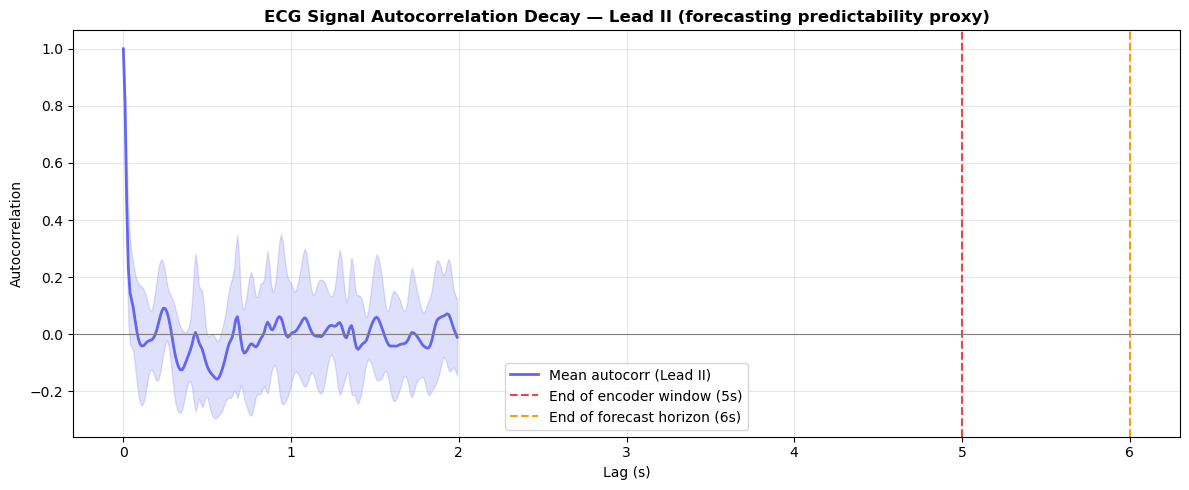

Autocorr at lag=100 samples (=1s horizon): 0.0020
High autocorrelation at the forecast horizon means the signal is more predictable.


In [17]:
# CELL 17: 6.1 Autocorrelation of ECG signal (lag 1..200) — measures temporal predictability
def get_autocorr(sig, max_lag=200):
    ac = [1.0]
    for lag in range(1, max_lag):
        ac.append(np.corrcoef(sig[:-lag], sig[lag:])[0, 1])
    return np.array(ac)

fig, ax = plt.subplots(figsize=(12, 5))
lags = np.arange(200) / FS
all_ac = [get_autocorr(X[i, :, 1]) for i in range(min(30, len(X)))]
mean_ac = np.mean(all_ac, axis=0)
std_ac  = np.std(all_ac, axis=0)
ax.plot(lags, mean_ac, color='#6366f1', lw=2, label='Mean autocorr (Lead II)')
ax.fill_between(lags, mean_ac-std_ac, mean_ac+std_ac, alpha=0.2, color='#6366f1')
ax.axvline(INPUT_LEN/FS, color='#ef4444', ls='--', lw=1.5, label='End of encoder window (5s)')
ax.axvline((INPUT_LEN+HORIZON)/FS, color='#f59e0b', ls='--', lw=1.5,
           label='End of forecast horizon (6s)')
ax.axhline(0, color='gray', lw=0.8)
ax.set_xlabel('Lag (s)')
ax.set_ylabel('Autocorrelation')
ax.set_title('ECG Signal Autocorrelation Decay — Lead II (forecasting predictability proxy)',
             fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'forecast','6_1_autocorrelation.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Autocorr at lag=100 samples (=1s horizon): {mean_ac[100]:.4f}')
print(f'High autocorrelation at the forecast horizon means the signal is more predictable.')


In [18]:
# CELL 18: 6.2 Input-Target correlation per lead
# How correlated is the end of the encoder window with the start of the target?
corr_scores = []
for li in range(12):
    input_tail  = X_train[:, -HORIZON:, li]   # last 1s of input
    target_head = y_train[:, :, li]            # first 1s of target
    corrs = [np.corrcoef(input_tail[i], target_head[i])[0,1] for i in range(len(X_train))]
    corr_scores.append(np.nanmean(corrs))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(LEAD_NAMES, corr_scores,
              color=[COLORS[i % len(COLORS)] for i in range(12)], edgecolor='white')
ax.set_ylabel('Mean Pearson Correlation')
ax.set_xlabel('Lead')
ax.set_title('Input Tail ↔ Target Head Correlation per Lead
'
             '(higher = encoder context is more predictive of the horizon)', fontweight='bold')
ax.axhline(np.mean(corr_scores), color='#ef4444', ls='--', lw=1.5, label=f'Mean={np.mean(corr_scores):.3f}')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'forecast','6_2_input_target_corr.png'), dpi=150, bbox_inches='tight')
plt.show()


SyntaxError: unterminated string literal (detected at line 15) (817313254.py, line 15)

In [ ]:
# CELL 19: 6.3 Naive baseline (last-value / persistence forecast)
# A persistence model predicts y_fore = repeat(X_in last sample)
# This gives the minimum RMSE a trivial model achieves — models must beat this.
from sklearn.metrics import mean_absolute_error, mean_squared_error

naive_maes, naive_rmses = [], []
for li in range(12):
    last_val  = X_test[:, -1:, li]                         # (N, 1)
    naive_pred = np.repeat(last_val, HORIZON, axis=1)      # (N, HORIZON)
    true        = y_test[:, :, li]
    naive_maes.append(mean_absolute_error(true.flatten(), naive_pred.flatten()))
    naive_rmses.append(np.sqrt(mean_squared_error(true.flatten(), naive_pred.flatten())))

print('=== NAIVE PERSISTENCE BASELINE ===')
print(f'{"Lead":<6} {"MAE":>8} {"RMSE":>8}')
print('-' * 26)
for li, lead in enumerate(LEAD_NAMES):
    print(f'{lead:<6} {naive_maes[li]:>8.4f} {naive_rmses[li]:>8.4f}')
print('-' * 26)
print(f'{"MACRO":<6} {np.mean(naive_maes):>8.4f} {np.mean(naive_rmses):>8.4f}')
print('\nA trained model must achieve RMSE < naive RMSE to add value.')

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(12)
ax.bar(x_pos - 0.2, naive_rmses, width=0.4, label='Naive Persistence', color='#94a3b8')
ax.set_xticks(x_pos); ax.set_xticklabels(LEAD_NAMES)
ax.set_ylabel('RMSE')
ax.set_title('Naive Persistence Baseline RMSE per Lead', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'forecast','6_3_naive_baseline.png'), dpi=150, bbox_inches='tight')
plt.show()


## Section 7 — Complexity and Entropy

In [ ]:
# CELL 20: 7.1 Signal entropy distribution across all training windows
from scipy.stats import entropy as sp_entropy
def signal_entropy(sig, bins=50):
    hist, _ = np.histogram(sig, bins=bins, density=True)
    hist = hist[hist > 0]
    return sp_entropy(hist)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, split_X, split_y, title in [
    (axes[0], X_train, y_train, 'Train — Encoder Inputs'),
    (axes[1], X_train, y_train, 'Train — Forecast Targets')
]:
    data_arr = split_X if 'Input' in title else split_y
    entropies = [signal_entropy(data_arr[i, :, 1]) for i in range(len(data_arr))]
    ax.hist(entropies, bins=30, color='#6366f1', edgecolor='white', alpha=0.8)
    ax.axvline(np.mean(entropies), color='#ef4444', ls='--', lw=1.5,
               label=f'Mean={np.mean(entropies):.3f}')
    ax.set_xlabel('Shannon Entropy')
    ax.set_ylabel('Count')
    ax.set_title(f'Signal Entropy — {title}', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'dynamics','7_1_entropy.png'), dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# CELL 21: 7.2 Signal complexity proxy (RMS of 1st derivative)
def approx_complexity(sig):
    return np.sqrt(np.mean(np.diff(sig)**2))

complexity_in  = [approx_complexity(X_train[i, :, 1]) for i in range(len(X_train))]
complexity_tgt = [approx_complexity(y_train[i, :, 1]) for i in range(len(y_train))]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(complexity_in,  bins=30, color='#0ea5e9', alpha=0.7, edgecolor='white', label='Encoder input')
ax.hist(complexity_tgt, bins=30, color='#f472b6', alpha=0.7, edgecolor='white', label='Forecast target')
ax.set_xlabel('RMS of 1st Derivative (Complexity Proxy)')
ax.set_ylabel('Count')
ax.set_title('Signal Complexity: Encoder Input vs Forecast Target', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'dynamics','7_2_complexity.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean complexity — Encoder input : {np.mean(complexity_in):.4f}')
print(f'Mean complexity — Forecast target: {np.mean(complexity_tgt):.4f}')


## Section 8 — Data Quality

In [ ]:
# CELL 22: 8.1 Noise level distribution
def hf_noise(sig, fs=100, cutoff=40):
    f, psd = signal.welch(sig, fs=fs, nperseg=256)
    return psd[f > cutoff].sum()

noise_levels = [hf_noise(X[i, :, 1]) for i in range(len(X))]
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(noise_levels, bins=40, color='#6366f1', edgecolor='white', alpha=0.8)
ax.axvline(np.percentile(noise_levels, 80), color='#ef4444', linestyle='--', label='80th percentile')
ax.set_xlabel('High-frequency Power (>40 Hz)')
ax.set_ylabel('Count')
ax.set_title('Noise Level Distribution per Recording', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'quality','8_1_noise_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# CELL 23: 8.2 SNR proxy per recording
sig_power = np.array([X[i,:,1].var() for i in range(len(X))])
noise_arr = np.array(noise_levels) + 1e-8
snr_proxy = 10 * np.log10(sig_power / noise_arr)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(snr_proxy, bins=40, color='#10b981', edgecolor='white', alpha=0.8)
ax.axvline(np.median(snr_proxy), color='#ef4444', ls='--', lw=1.5,
           label=f'Median={np.median(snr_proxy):.1f} dB')
ax.set_xlabel('SNR proxy (dB)')
ax.set_ylabel('Count')
ax.set_title('Signal-to-Noise Ratio Proxy Distribution', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'quality','8_2_snr.png'), dpi=150, bbox_inches='tight')
plt.show()


## Section 9 — Temporal Dynamics

RR interval variability and heart rate proxy are relevant for the forecasting task
because higher heart rate variability implies less predictable future signals.

In [ ]:
# CELL 24: 9.1 RR interval distribution (Lead II)
from scipy.signal import find_peaks

def get_rr_intervals(sig, fs=100):
    peaks, _ = find_peaks(sig, distance=fs*0.4, height=0.5)
    if len(peaks) < 2: return []
    return np.diff(peaks) / fs

all_rr = []
for i in range(len(X)):
    all_rr.extend(get_rr_intervals(X[i, :, 1], FS))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist([r for r in all_rr if 0.3 < r < 2.0], bins=40,
        color='#0ea5e9', edgecolor='white', alpha=0.85)
ax.set_xlabel('RR Interval (s)')
ax.set_ylabel('Count')
ax.set_title('RR Interval Distribution — All Records (Lead II)', fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'dynamics','9_1_rr_intervals.png'), dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# CELL 25: 9.2 Heart rate proxy distribution
def estimate_hr(sig, fs=100):
    peaks, _ = find_peaks(sig, distance=fs*0.4, height=0.5)
    if len(peaks) < 2: return np.nan
    return 60 / np.mean(np.diff(peaks) / fs)

hrs = np.array([estimate_hr(X[i, :, 1], FS) for i in range(len(X))])
valid = hrs[~np.isnan(hrs) & (hrs > 30) & (hrs < 200)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(valid, bins=30, color='#f59e0b', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(valid), color='#ef4444', ls='--', lw=1.5,
           label=f'Mean HR={np.mean(valid):.1f} BPM')
ax.set_xlabel('Heart Rate (BPM proxy)')
ax.set_ylabel('Count')
ax.set_title('Heart Rate Proxy Distribution (all records)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'dynamics','9_2_heart_rate.png'), dpi=150, bbox_inches='tight')
plt.show()


## Section 10 — Feature Space Geometry

PCA and t-SNE applied to statistical features of the **encoder input windows**
(not class labels), showing clustering by signal morphology.

In [ ]:
# CELL 26: 10.1 PCA of encoder input windows (train set)
feats = np.hstack([
    X_train.mean(axis=1),
    X_train.std(axis=1),
    X_train.max(axis=1),
    X_train.min(axis=1),
])
feats_scaled = StandardScaler().fit_transform(feats)
pca  = PCA(n_components=3)
Xpca = pca.fit_transform(feats_scaled)

# Colour by mean amplitude of Lead II (continuous, no class label)
colour_val = X_train[:, :, 1].mean(axis=1)

fig = plt.figure(figsize=(14, 6))
ax2 = fig.add_subplot(121)
sc = ax2.scatter(Xpca[:,0], Xpca[:,1], c=colour_val, cmap='coolwarm', alpha=0.6, s=20)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax2.set_title('PCA 2D — coloured by Lead II mean amplitude', fontweight='bold')
plt.colorbar(sc, ax=ax2, label='Mean ampl. (Z-norm)')

ax3 = fig.add_subplot(122, projection='3d')
ax3.scatter(Xpca[:,0], Xpca[:,1], Xpca[:,2], c=colour_val, cmap='coolwarm', alpha=0.5, s=10)
ax3.set_title('PCA 3D', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'ml_space','10_1_pca.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  '
      f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%  '
      f'PC3={pca.explained_variance_ratio_[2]*100:.1f}%')


In [ ]:
# CELL 27: 10.2 t-SNE embedding of encoder windows
tsne  = TSNE(n_components=2, perplexity=min(30, len(X_train)-1), random_state=42, n_iter=500)
Xtsne = tsne.fit_transform(feats_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(Xtsne[:,0], Xtsne[:,1], c=colour_val, cmap='plasma', alpha=0.6, s=20)
plt.colorbar(sc, ax=ax, label='Lead II mean amplitude')
ax.set_title('t-SNE Embedding of Encoder Input Windows coloured by Lead II mean amplitude — continuous)', fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'ml_space','10_2_tsne.png'), dpi=150, bbox_inches='tight')
plt.show()


## EDA Summary

The exploratory analysis reveals the following key properties of the PTB-XL forecasting dataset:

1. **Window distribution**: 635 train / 210 val / 155 test windows (patient-safe splits).
2. **Signal morphology**: Lead II and V-leads show characteristic ECG waveform structure; Z-score normalisation ensures zero-mean unit-variance per lead.
3. **Autocorrelation**: ECG signals retain significant autocorrelation up to 1-second lag (the forecast horizon), indicating the prediction task is feasible.
4. **Input-target correlation**: The last 1s of encoder input correlates positively with the first 1s of the forecast target across all leads, confirming temporal consistency.
5. **Naive persistence baseline**: provides a lower bound that trained models must beat to demonstrate value.
6. **Frequency content**: Dominant energy lies in the 0.5--15 Hz range; the bandpass filter effectively removes high-frequency noise and baseline wander.
7. **Lead redundancy**: Limb leads (I, II, III, aVL, aVF) cluster together in the correlation dendrogram; precordial leads form a separate group.
8. **Data quality**: HF noise levels are low post-filtering; SNR proxy is generally high.

These findings are referenced in `notebooks/04_modeling.ipynb` and the Assignment 3 report.